# Step 8c – Diffusion Speed across Years and Cities

This notebook investigates whether the diffusion speed (adoption lag) of
open-source projects varies significantly across:

1. **Different origin years** – Has diffusion become faster or slower over time?
2. **Different cities** – Do some cities consistently adopt projects faster?
3. **Year × City interaction** – Do city-level patterns change over time?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA = Path('..') / 'data' / 'output'

city_attr = pd.read_csv(DATA / 'city_attributes.csv')
adoption  = pd.read_csv(DATA / 'city_project_adoption_events.csv')

print(f'city_attributes:              {city_attr.shape}')
print(f'city_project_adoption_events: {adoption.shape}')

city_attributes:              (148, 28)
city_project_adoption_events: (39158, 6)


---
## Data Preparation

- Extract **origin year** from `global_origin_month` (YYYYMM format).
- **Exclude originators** (`is_originator == 1`) because their lag is always 0 by
  definition – they do not represent genuine diffusion events.
- Merge `region` from city attributes for grouping.

In [2]:
df = adoption[adoption['is_originator'] == 0].copy()
df['origin_year'] = df['global_origin_month'].astype(str).str[:4].astype(int)
df = df.merge(city_attr[['city', 'region']], on='city', how='left')

print(f'Non-originator adoption events: {len(df):,}')
print(f'Origin years covered: {sorted(df["origin_year"].unique())}')
print(f'Cities involved: {df["city"].nunique()}')
print(f'\nLag statistics (months):')
df['lag'].describe().round(2)

Non-originator adoption events: 30,653
Origin years covered: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Cities involved: 148

Lag statistics (months):


count    30653.00
mean         8.03
std          9.19
min          0.00
25%          1.00
50%          5.00
75%         12.00
max         50.00
Name: lag, dtype: float64

---
## Part A – Overall Diffusion Speed Trend by Year

Is diffusion getting faster (lower lag) or slower over time?

In [3]:
yearly_stats = df.groupby('origin_year')['lag'].agg(
    count='count', mean='mean', median='median',
    std='std', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).round(2)
print('Adoption lag statistics by origin year:')
display(yearly_stats)

Adoption lag statistics by origin year:


,count,mean,median,std,q25,q75
origin_year,,,,,,
2022,4828,12.53,8.0,12.48,2.0,20.0
2023,11993,9.49,6.0,9.83,1.0,16.0
2024,7078,6.81,5.0,6.73,1.0,11.0
2025,6754,3.48,2.0,3.51,1.0,6.0


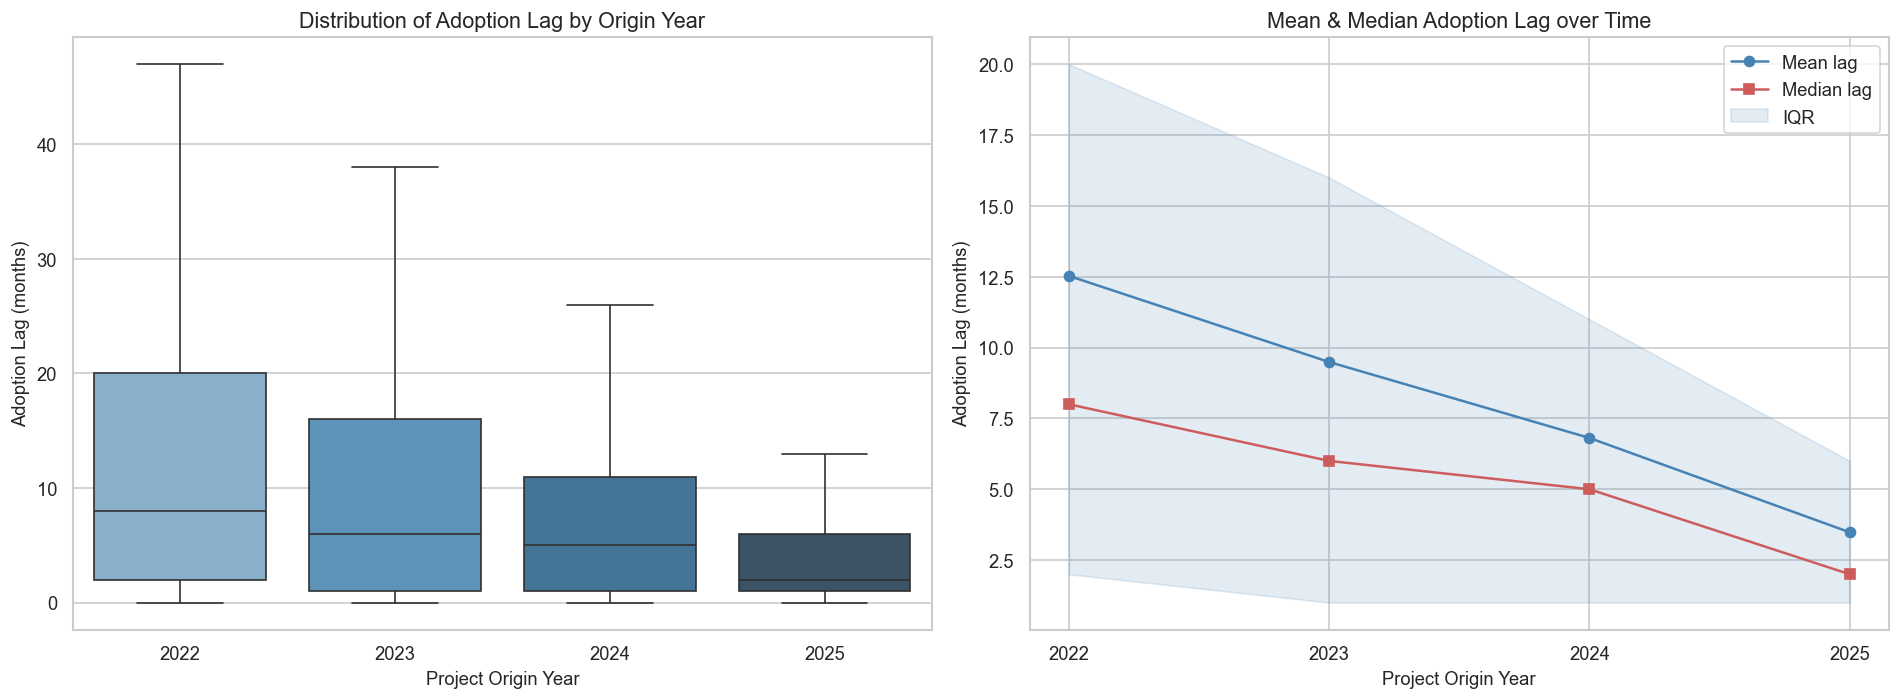

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: box plot of lag by year
year_order = sorted(df['origin_year'].unique())
sns.boxplot(data=df, x='origin_year', y='lag', order=year_order,
            showfliers=False, ax=axes[0], palette='Blues_d')
axes[0].set_title('Distribution of Adoption Lag by Origin Year')
axes[0].set_xlabel('Project Origin Year')
axes[0].set_ylabel('Adoption Lag (months)')

# Right: mean & median trend
axes[1].plot(yearly_stats.index, yearly_stats['mean'],
             marker='o', label='Mean lag', color='steelblue')
axes[1].plot(yearly_stats.index, yearly_stats['median'],
             marker='s', label='Median lag', color='indianred')
axes[1].fill_between(yearly_stats.index, yearly_stats['q25'], yearly_stats['q75'],
                     alpha=0.15, color='steelblue', label='IQR')
axes[1].set_title('Mean & Median Adoption Lag over Time')
axes[1].set_xlabel('Project Origin Year')
axes[1].set_ylabel('Adoption Lag (months)')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [5]:
# Kruskal-Wallis test: does lag differ significantly across origin years?
groups_year = [grp['lag'].values for _, grp in df.groupby('origin_year')]
stat_kw, p_kw = stats.kruskal(*groups_year)
print(f'Kruskal-Wallis test across origin years:')
print(f'  H = {stat_kw:.4f},  p = {p_kw:.6f}')
if p_kw < 0.05:
    print('  → Statistically significant difference in lag across years (p < 0.05).')
else:
    print('  → No statistically significant difference detected (p ≥ 0.05).')

Kruskal-Wallis test across origin years:
  H = 2157.7751,  p = 0.000000
  → Statistically significant difference in lag across years (p < 0.05).


---
## Part B – Diffusion Speed across Cities

Which cities adopt projects fastest / slowest?

In [6]:
MIN_ADOPTIONS = 50

city_lag = df.groupby('city')['lag'].agg(
    count='count', mean='mean', median='median', std='std'
).reset_index()
city_lag = city_lag[city_lag['count'] >= MIN_ADOPTIONS].sort_values('median')

print(f'Cities with ≥ {MIN_ADOPTIONS} non-originator adoption events: {len(city_lag)}')
print(f'\nTop 10 fastest-adopting cities (lowest median lag):')
display(city_lag.head(10).round(2))
print(f'\nTop 10 slowest-adopting cities (highest median lag):')
display(city_lag.tail(10).round(2))

Cities with ≥ 50 non-originator adoption events: 111

Top 10 fastest-adopting cities (lowest median lag):


,city,count,mean,median,std
10,Beijing,1473,5.72,2.0,8.05
135,Tokyo,1914,4.59,2.0,6.22
118,San Francisco,1955,7.49,3.0,9.95
122,Seattle,844,6.05,3.0,7.65
124,Shanghai,1147,5.75,3.0,7.26
136,Toronto,625,6.48,3.0,8.70
53,Hangzhou,700,6.38,3.0,8.19
83,Miami,170,6.89,3.0,9.40
95,New York,1098,6.76,4.0,8.19
75,London,1151,6.96,4.0,8.46



Top 10 slowest-adopting cities (highest median lag):


,city,count,mean,median,std
38,Delhi,123,10.80,8.0,10.57
31,Cologne,53,11.38,8.0,11.22
77,Lyon,87,9.22,8.0,7.92
23,Cairo,68,10.97,8.5,9.66
133,Tel Aviv,140,10.67,8.5,9.70
87,Moscow,123,11.93,9.0,11.06
103,Philadelphia,154,13.43,10.0,11.79
69,Kuala Lumpur,56,11.27,10.0,8.28
111,Rio de Janeiro,51,12.33,11.0,10.78
102,Perth,57,14.53,13.0,11.67


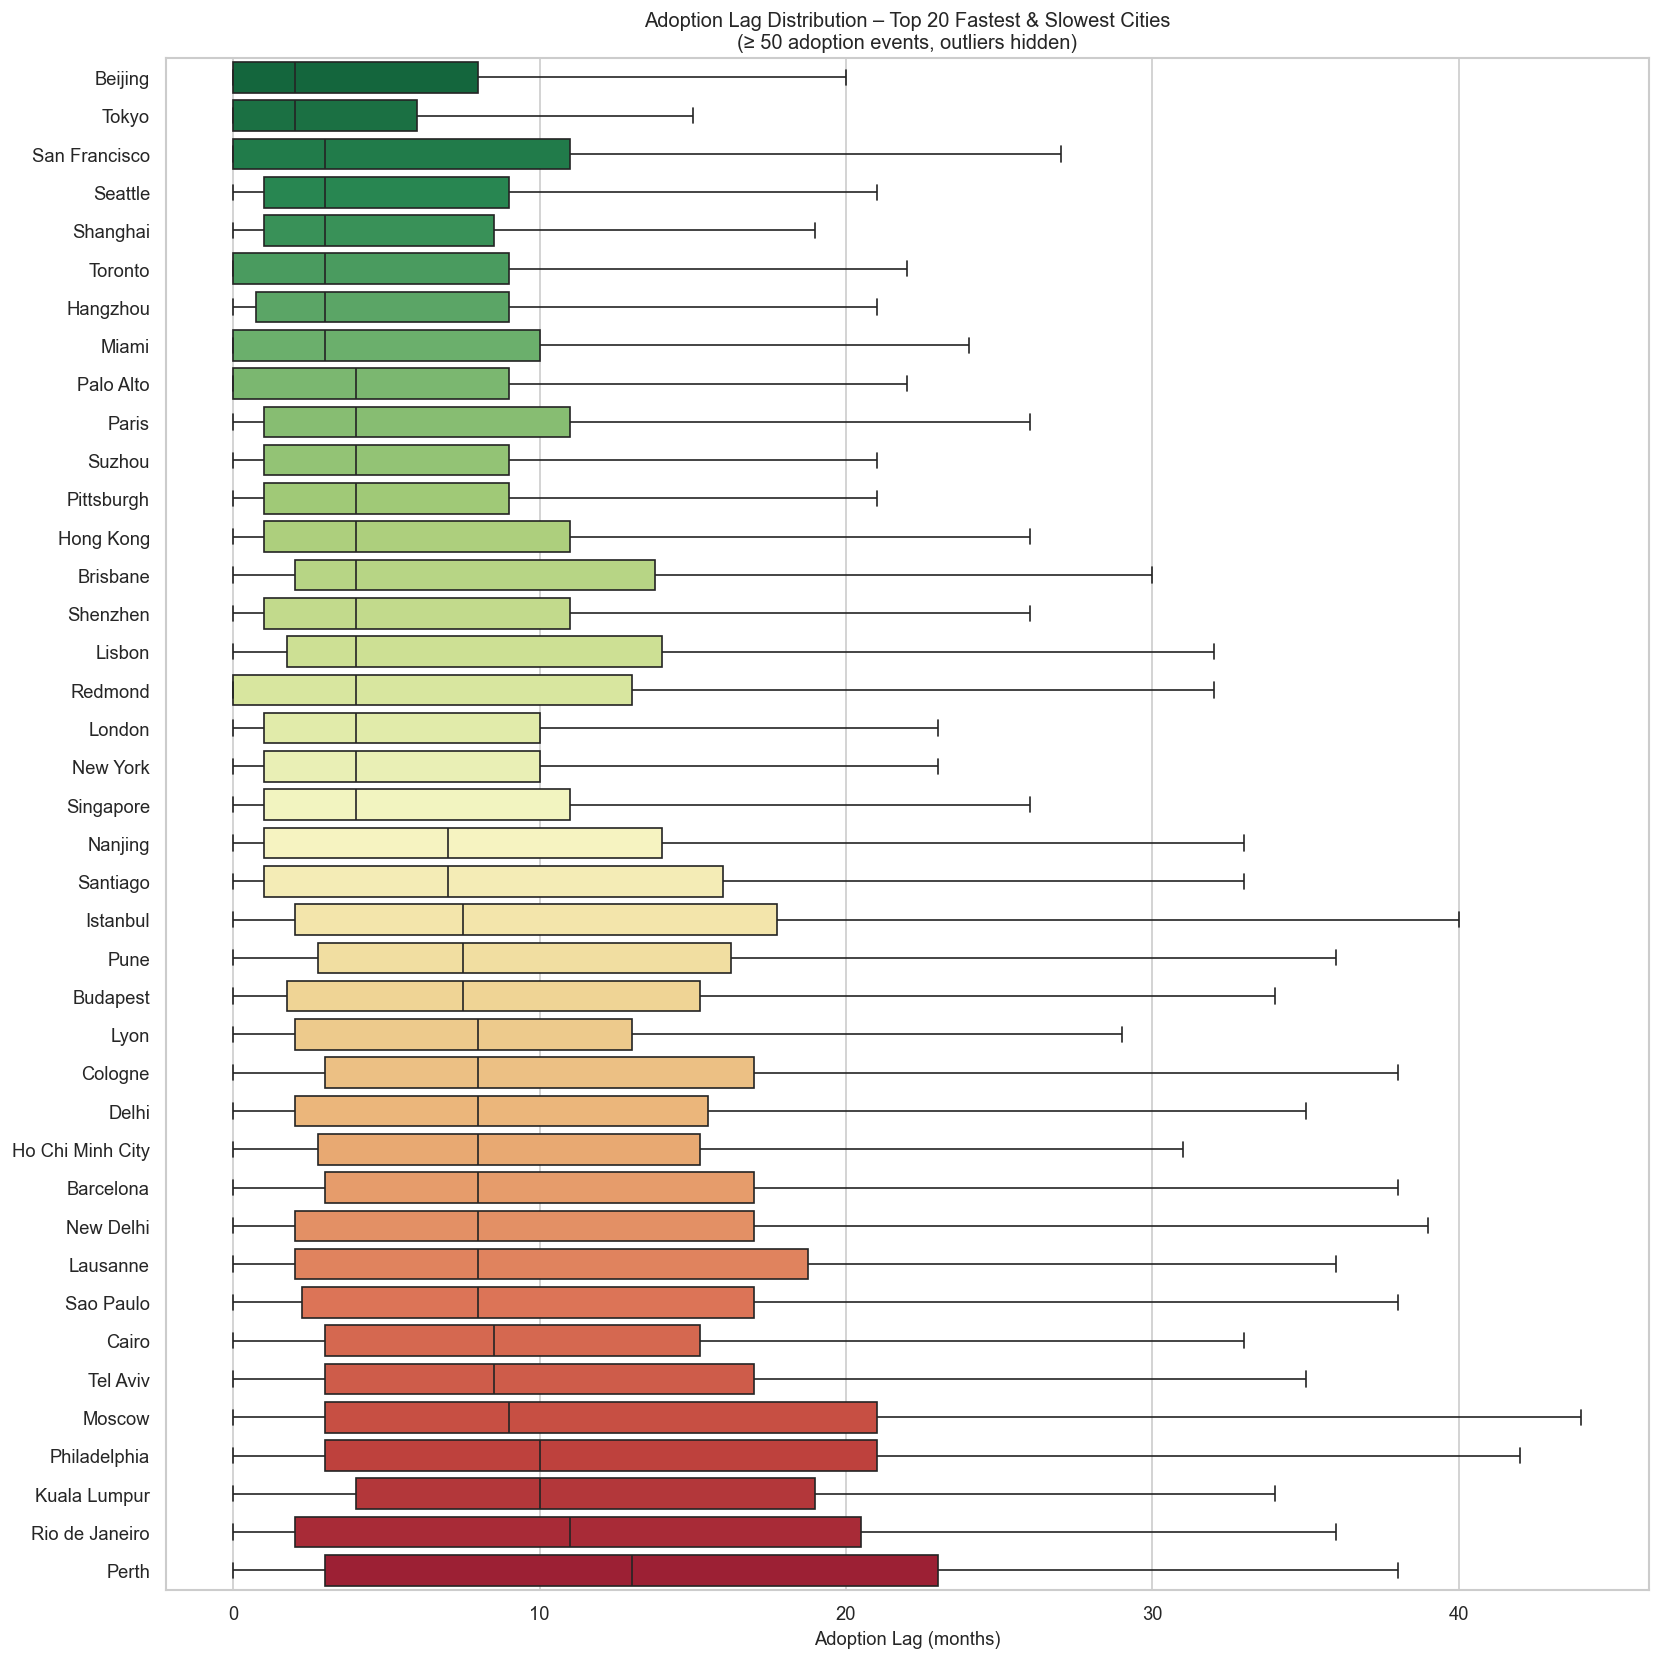

In [7]:
top_n = 20
top_cities = city_lag.head(top_n)['city'].tolist() + city_lag.tail(top_n)['city'].tolist()
top_cities = list(dict.fromkeys(top_cities))

plot_df = df[df['city'].isin(top_cities)].copy()
city_order = city_lag[city_lag['city'].isin(top_cities)].sort_values('median')['city'].tolist()

fig, ax = plt.subplots(figsize=(14, max(8, len(city_order) * 0.35)))
sns.boxplot(data=plot_df, y='city', x='lag', order=city_order,
            showfliers=False, palette='RdYlGn_r', ax=ax)
ax.set_title(f'Adoption Lag Distribution – Top {top_n} Fastest & Slowest Cities\n'
             f'(≥ {MIN_ADOPTIONS} adoption events, outliers hidden)', fontsize=12)
ax.set_xlabel('Adoption Lag (months)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [8]:
# Kruskal-Wallis test across cities (for those with enough data)
qualified_cities = city_lag['city'].tolist()
groups_city = [df[df['city'] == c]['lag'].values for c in qualified_cities]
stat_city, p_city = stats.kruskal(*groups_city)
print(f'Kruskal-Wallis test across {len(qualified_cities)} cities:')
print(f'  H = {stat_city:.4f},  p = {p_city:.6f}')
if p_city < 0.05:
    print('  → Statistically significant difference in lag across cities (p < 0.05).')
else:
    print('  → No statistically significant difference detected (p ≥ 0.05).')

Kruskal-Wallis test across 111 cities:
  H = 1439.0204,  p = 0.000000
  → Statistically significant difference in lag across cities (p < 0.05).


---
## Part C – Year × City Interaction: Heatmap

Do city-level diffusion patterns change across years?

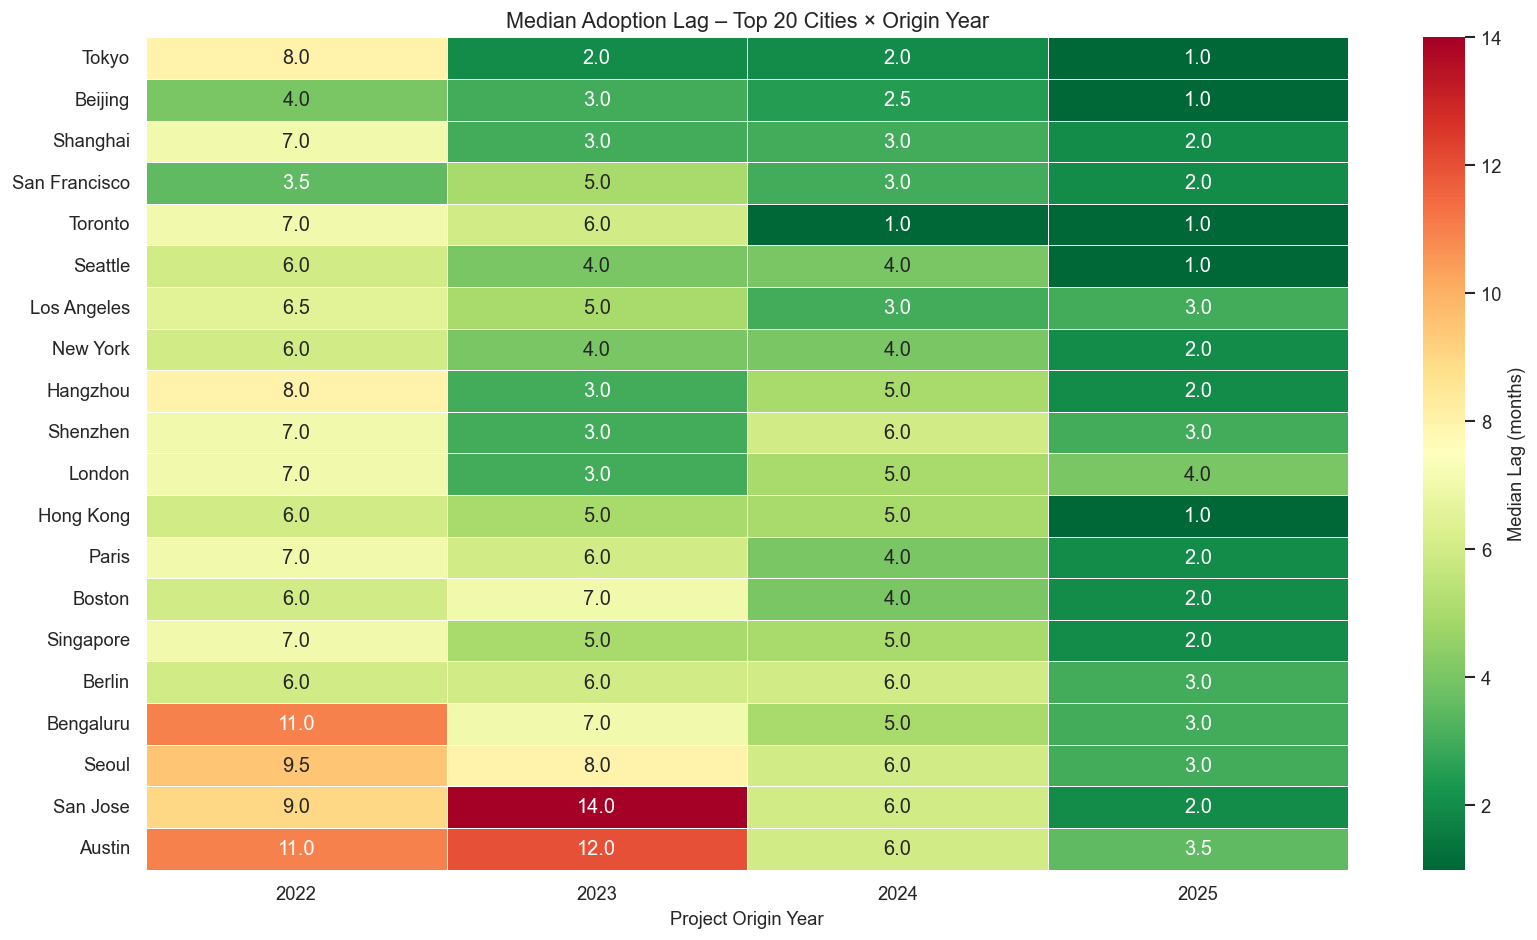

In [9]:
TOP_K = 20
top_k_cities = (
    df.groupby('city')['lag'].count()
    .nlargest(TOP_K).index.tolist()
)

heatmap_data = (
    df[df['city'].isin(top_k_cities)]
    .groupby(['city', 'origin_year'])['lag']
    .median()
    .unstack(fill_value=np.nan)
)
heatmap_data = heatmap_data.loc[
    heatmap_data.median(axis=1).sort_values().index
]

fig, ax = plt.subplots(figsize=(14, max(6, TOP_K * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Median Lag (months)'})
ax.set_title(f'Median Adoption Lag – Top {TOP_K} Cities × Origin Year', fontsize=13)
ax.set_xlabel('Project Origin Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## Part D – Regional Diffusion Speed by Year

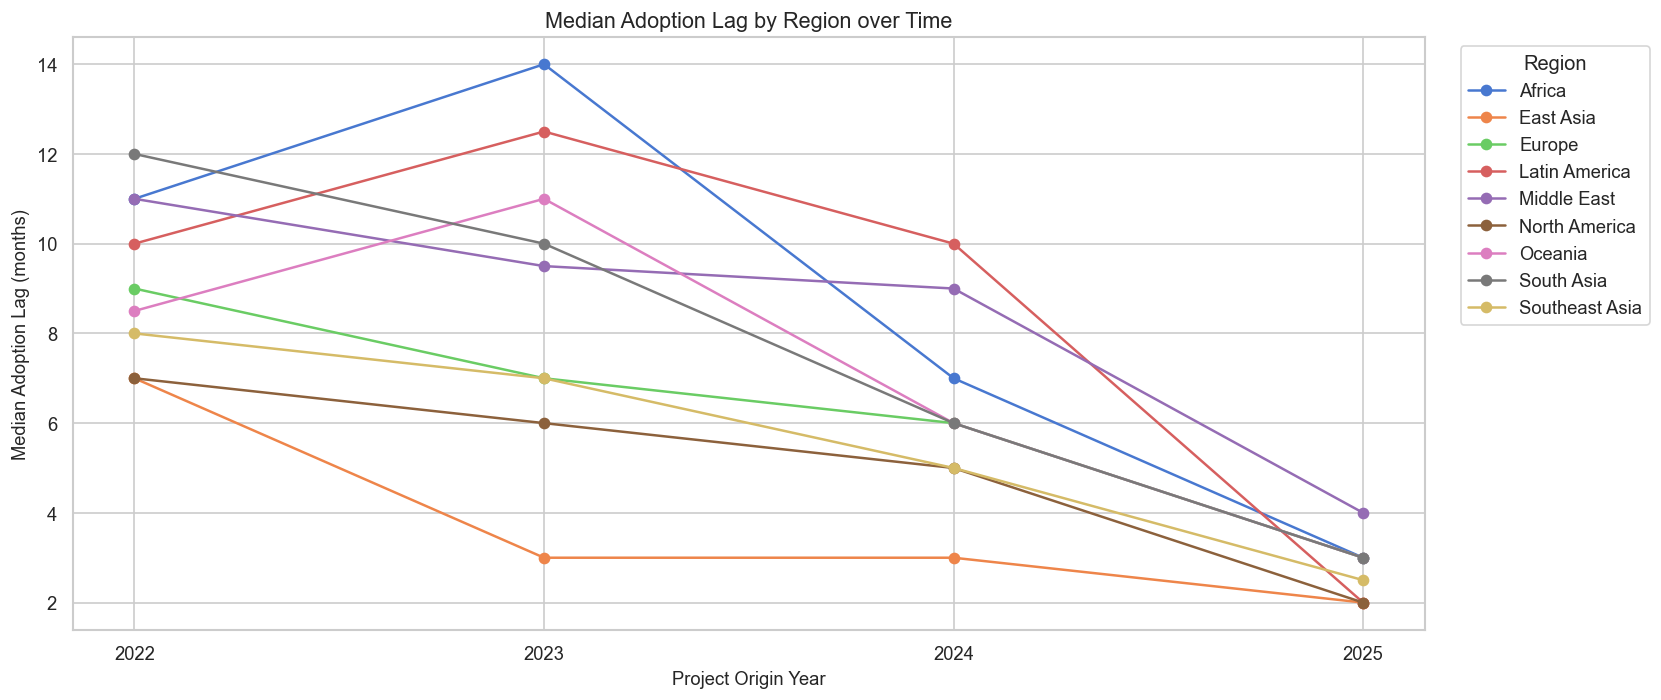

In [10]:
region_year = (
    df.groupby(['region', 'origin_year'])['lag']
    .agg(['median', 'count'])
    .reset_index()
)
region_year = region_year[region_year['count'] >= 10]

fig, ax = plt.subplots(figsize=(14, 6))
for region in sorted(region_year['region'].unique()):
    sub = region_year[region_year['region'] == region]
    ax.plot(sub['origin_year'], sub['median'], marker='o', label=region)

ax.set_title('Median Adoption Lag by Region over Time', fontsize=13)
ax.set_xlabel('Project Origin Year')
ax.set_ylabel('Median Adoption Lag (months)')
ax.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

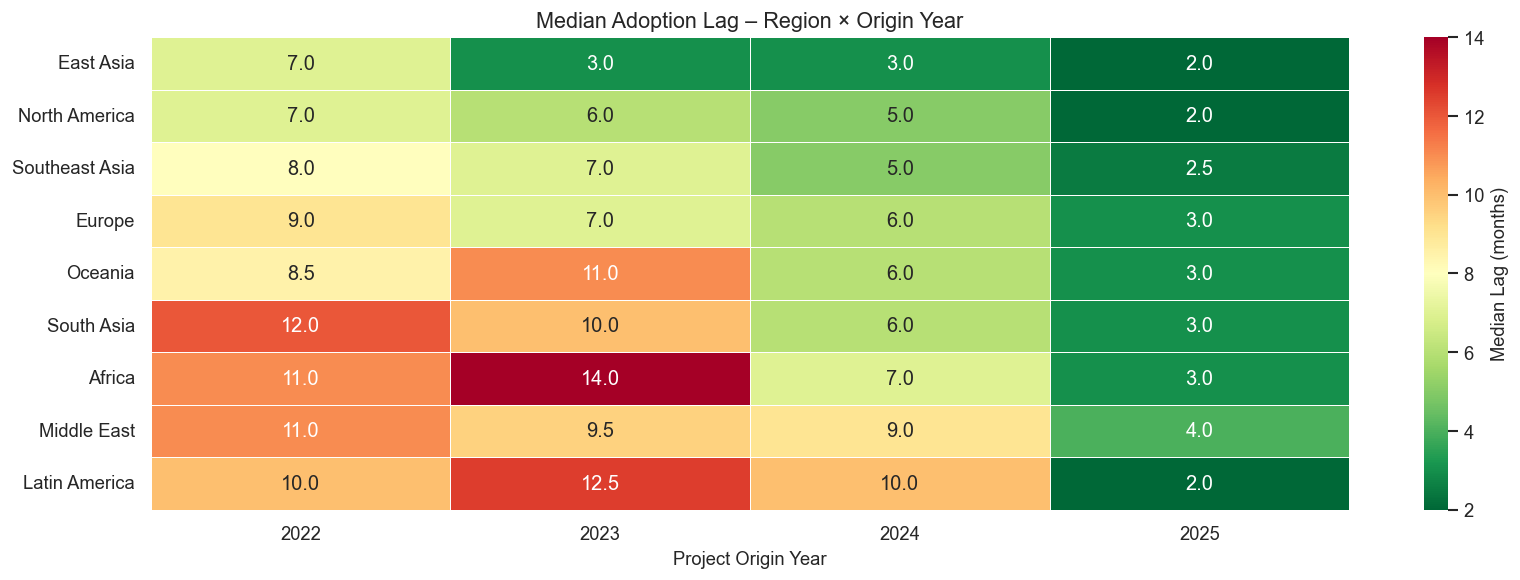

In [11]:
# Regional heatmap
region_heatmap = (
    df.groupby(['region', 'origin_year'])['lag']
    .median()
    .unstack(fill_value=np.nan)
)
region_heatmap = region_heatmap.loc[
    region_heatmap.median(axis=1).sort_values().index
]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(region_heatmap, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Median Lag (months)'})
ax.set_title('Median Adoption Lag – Region × Origin Year', fontsize=13)
ax.set_xlabel('Project Origin Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## Part E – Year-over-Year Change for Top Cities

Track how median lag evolves year-over-year for the most active cities.

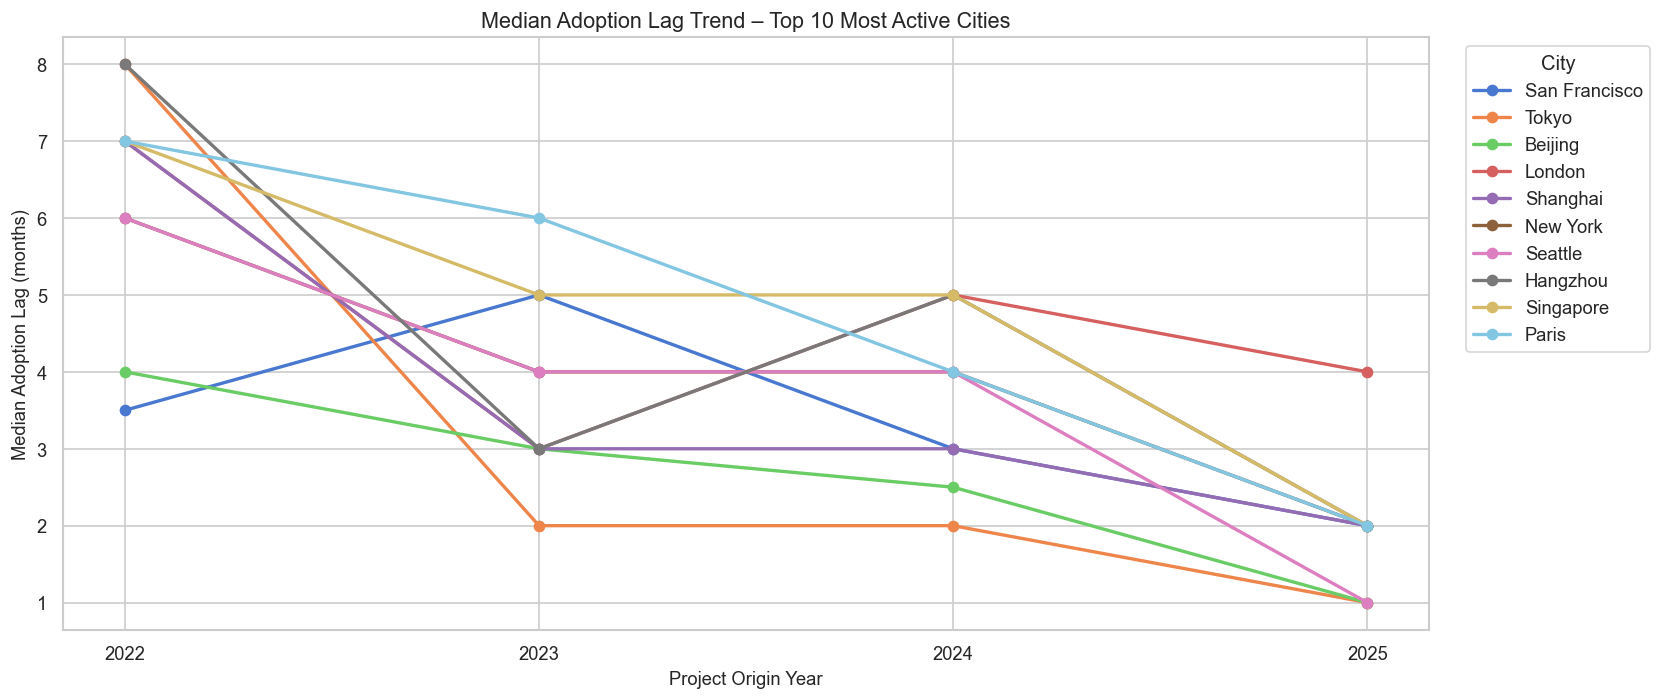

In [12]:
TRACK_N = 10
track_cities = (
    df.groupby('city')['lag'].count()
    .nlargest(TRACK_N).index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
for city in track_cities:
    sub = df[df['city'] == city].groupby('origin_year')['lag'].median()
    sub = sub[sub.index.map(lambda y: df[(df['city'] == city) & (df['origin_year'] == y)].shape[0] >= 5)]
    if len(sub) >= 2:
        ax.plot(sub.index, sub.values, marker='o', label=city, linewidth=2)

ax.set_title(f'Median Adoption Lag Trend – Top {TRACK_N} Most Active Cities', fontsize=13)
ax.set_xlabel('Project Origin Year')
ax.set_ylabel('Median Adoption Lag (months)')
ax.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

---
## Summary

| Dimension | Key finding |
| --- | --- |
| **By Year** | Kruskal-Wallis test checks whether diffusion speed differs across origin years |
| **By City** | Kruskal-Wallis test checks whether different cities show different adoption lags |
| **Year × City** | Heatmap reveals whether city-level patterns are stable or evolving |
| **By Region** | Regional trends show whether geographic clusters follow distinct trajectories |

These results inform later modelling by highlighting temporal and spatial heterogeneity
in knowledge diffusion dynamics.